# Current Loop Tuning with pyx2ctune

This notebook walks through the current loop PI gain tuning workflow using the MCAF test harness and X2Cscope.

**Workflow:**
1. Configure serial port and file paths
2. Connect to the target board
3. Read current PI gains from firmware
4. Enter current test mode (activates test harness guard)
5. Set PI gains (engineering units: V/A, V/A/s)
6. Configure scope and start square-wave perturbation
7. Capture step response and analyze metrics
8. Iterate on gains with quick re-capture
9. (Optional) Automated Kp sweep
10. Clean up

All variable reads, writes, and events are logged to `logs/session_*.log`.

**Reference:** [MCAF Current Loop Tuning (section 5.1.6)](https://microchiptech.github.io/mcaf-doc/9.0.1/algorithms/foc/tuning.html)

## 1. Configuration

Edit these paths to match your setup.

In [1]:
# ── Edit these for your setup ──────────────────────────────────────
SERIAL_PORT = "/dev/tty.usbmodem21202"  # macOS; use "COM3" on Windows
BAUD_RATE = 115200

ELF_FILE = "../motorbench/mclv-48v-300w/mclv-48v-300w.X/dist/default/debug/mclv-48v-300w.X.debug.elf"
PARAMS_JSON = "../motorbench/mclv-48v-300w/mclv-48v-300w.X/mcc_generated_files/motorBench/aux-files/parameters.json"

# ── Logging (file only; change WARNING to INFO to see inline) ─────
import logging
logging.basicConfig(
    level=logging.WARNING,
    format="%(asctime)s %(levelname)-5s %(name)s  %(message)s",
    datefmt="%H:%M:%S",
)

## 2. Connect to Target

In [2]:
from pyx2ctune import TuningSession

session = TuningSession(
    port=SERIAL_PORT,
    elf_file=ELF_FILE,
    baud_rate=BAUD_RATE,
    parameters_json=PARAMS_JSON,
)
print(session)
print(session.params)

TuningSession(port='/dev/tty.usbmodem21202', baud_rate=115200, elf='mclv-48v-300w.X.debug.elf')
ParameterDB(version='R9/RC31', parameters=148)


## 3. Check Current Gains

Read the current PI gains from the firmware before making changes.

In [3]:
gains = session.current.get_gains(axis="q")
print(f"Q-axis current loop gains:")
print(f"  Kp = {gains.kp:.4f} {gains.kp_units}  (counts={gains.kp_counts}, Q{gains.kp_shift})")
print(f"  Ki = {gains.ki:.2f} {gains.ki_units}  (counts={gains.ki_counts}, Q{gains.ki_shift})")

Q-axis current loop gains:
  Kp = 3.0000 V/A  (counts=28546, Q14)
  Ki = 5000.40 V/A/s  (counts=4758, Q15)


## 4. Enter Current Test Mode

This activates the test harness guard and enters `OM_FORCE_CURRENT` mode.

**Safety note:** The guard timeout auto-refreshes in the background. If the connection drops, the guard expires after ~3.3 seconds and the firmware reverts to safe operation.

In [4]:
session.test_harness.enter_current_test_mode()
print(f"Guard active: {session.test_harness.guard_active}")
print(f"Operating mode: {session.test_harness.get_operating_mode().name}")

Guard active: True
Operating mode: FORCE_CURRENT


## 5. Set PI Gains

Adjust Kp and Ki here. Values are in engineering units (V/A and V/A/s).

**Guidelines from MCAF docs:**
- Default (conservative): phase margin 80°, PI phase lag 45° → low bandwidth
- Well-tuned: phase margin 45-70°, PI phase lag 8-20° → higher bandwidth
- Decreasing phase margin raises both Kp and Ki
- Decreasing PI phase lag raises Kp, lowers Ki

In [10]:
# ── Adjust these gains (initialized from step 3 readback) ─────────
KP = gains.kp   # V/A
KI = gains.ki   # V/A/s

# Uncomment and modify to change gains:
# KP = 0.614
# KI = 1268.0

result = session.current.set_gains(kp=KP, ki=KI)
print(f"Set Kp = {result.kp:.4f} V/A  (counts={result.kp_counts}, Q{result.kp_shift})")
print(f"Set Ki = {result.ki:.2f} V/A/s  (counts={result.ki_counts}, Q{result.ki_shift})")

Set Kp = 3.0000 V/A  (counts=28546, Q14)
Set Ki = 5000.40 V/A/s  (counts=4758, Q15)


## 6. Configure Scope & Start Perturbation

Sets up scope channels for the q-axis current loop and starts a square-wave perturbation.

In [6]:
AXIS = "q"
AMPLITUDE = 500      # perturbation amplitude in counts
HALFPERIOD = 100     # half-period in PWM cycles (100 @ 20kHz = 5ms → 100Hz square wave)

session.capture.configure_current_loop(axis=AXIS, sample_time=1)
session.current.setup_step_test(axis=AXIS, amplitude=AMPLITUDE, halfperiod=HALFPERIOD)
print(f"Perturbation active: {AXIS}-axis, amplitude={AMPLITUDE}, halfperiod={HALFPERIOD}")

Perturbation active: q-axis, amplitude=500, halfperiod=100


## 7. Capture & Analyze Step Response

**Re-run this cell** after adjusting gains (cell 5) to see the updated response.
You don't need to re-run the cells above -- just change gains and re-capture.

Step Response Metrics (17 steps detected):
  Overshoot:          4.4%
  Rise time:          14 µs
  Settling time:      1397 µs
  Steady-state error: 0.032


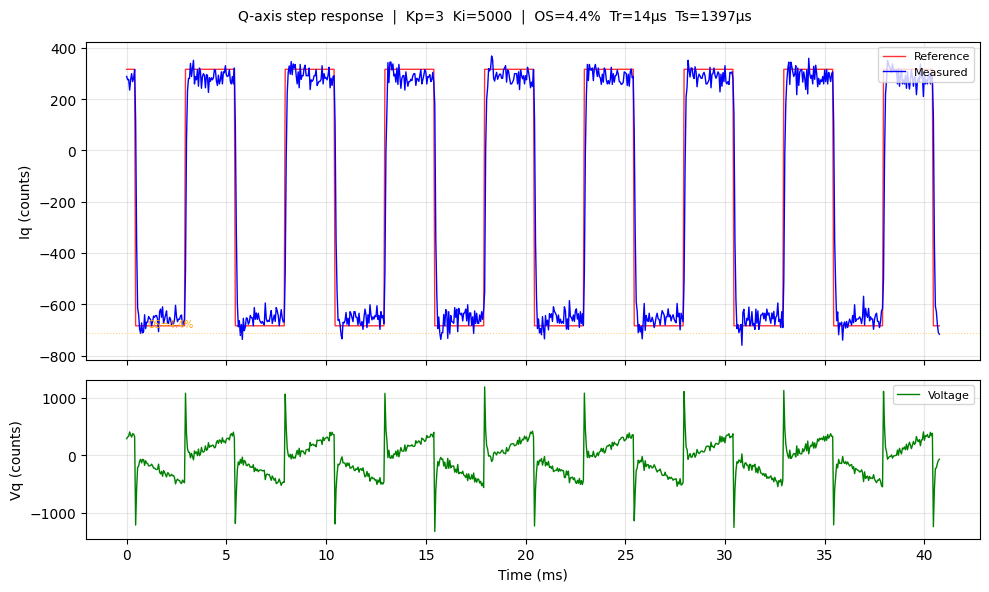

In [7]:
%matplotlib inline
from pyx2ctune.analysis import compute_metrics
from pyx2ctune.plotting import plot_step_response

response = session.capture.capture_frame(timeout=10.0)
metrics = compute_metrics(response)

print(f"Step Response Metrics ({metrics.n_steps} steps detected):")
print(f"  Overshoot:          {metrics.overshoot:.1%}")
print(f"  Rise time:          {metrics.rise_time_us:.0f} \u00b5s")
print(f"  Settling time:      {metrics.settling_time_us:.0f} \u00b5s")
print(f"  Steady-state error: {metrics.steady_state_error:.3f}")

plot_step_response(response, metrics, show=True);

## 8. Iterate: Change Gains & Re-Capture

Use this cell for quick iteration. Change `KP` and `KI`, run the cell,
and see the new step response immediately.

Kp=10.0000 V/A, Ki=10000.00 V/A/s
  OS=22.5%  Tr=31µs  Ts=2132µs  SSE=0.019


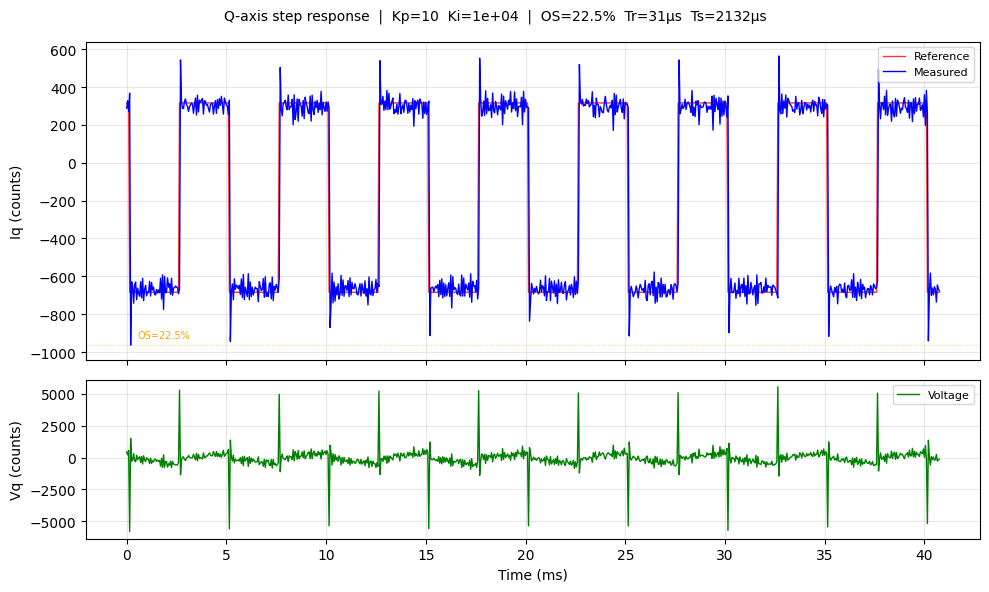

In [8]:
# ── Quick iteration cell ───────────────────────────────────────────
KP = 10    # V/A   (try a higher-bandwidth setting)
KI = 10000  # V/A/s

session.current.set_gains(kp=KP, ki=KI)

response = session.capture.capture_frame(timeout=10.0)
metrics = compute_metrics(response)

print(f"Kp={KP:.4f} V/A, Ki={KI:.2f} V/A/s")
print(f"  OS={metrics.overshoot:.1%}  Tr={metrics.rise_time_us:.0f}\u00b5s  Ts={metrics.settling_time_us:.0f}\u00b5s  SSE={metrics.steady_state_error:.3f}")
plot_step_response(response, metrics, show=True);

## 9. (Optional) Automated Gain Sweep

Sweep Kp over a range with fixed Ki and collect metrics.

Kp=0.50: OS=39.1%  Tr=203µs  Ts=1994µs
Kp=1.00: OS=24.5%  Tr=139µs  Ts=1588µs
Kp=2.00: OS=9.9%  Tr=55µs  Ts=1678µs
Kp=3.00: OS=5.2%  Tr=125µs  Ts=1879µs
Kp=4.00: OS=3.1%  Tr=80µs  Ts=1741µs
Kp=5.00: OS=3.5%  Tr=0µs  Ts=1888µs
Kp=6.00: OS=5.0%  Tr=58µs  Ts=2044µs
Kp=7.00: OS=11.9%  Tr=0µs  Ts=2100µs


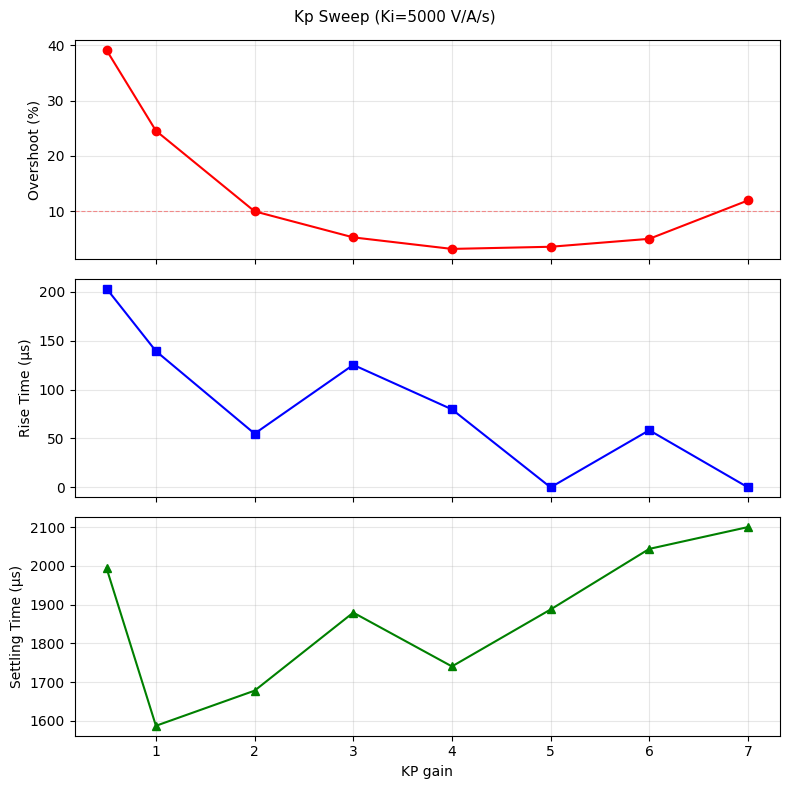

In [9]:
import time
from pyx2ctune.plotting import plot_gain_sweep

KI_FIXED = 5000
KP_VALUES = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0]

results = []
for kp in KP_VALUES:
    session.current.set_gains(kp=kp, ki=KI_FIXED)
    time.sleep(0.2)
    resp = session.capture.capture_frame(timeout=10.0)
    m = compute_metrics(resp)
    print(f"Kp={kp:.2f}: OS={m.overshoot:.1%}  Tr={m.rise_time_us:.0f}\u00b5s  Ts={m.settling_time_us:.0f}\u00b5s")
    results.append({"kp": kp, "ki": KI_FIXED, "overshoot": m.overshoot,
                    "rise_time_us": m.rise_time_us, "settling_time_us": m.settling_time_us,
                    "steady_state_error": m.steady_state_error})

plot_gain_sweep(results, x_key="kp", show=True, title=f"Kp Sweep (Ki={KI_FIXED:.0f} V/A/s)");

## 10. Clean Up

Stop perturbation, exit test mode, and disconnect.

**Always run this cell when you're done** to leave the motor in a safe state.

In [11]:
session.current.stop_perturbation()
session.test_harness.exit_test_mode()
session.disconnect()
print("Disconnected. Motor returned to normal operation.")

Disconnected. Motor returned to normal operation.
